# Phase 3: Exploratory Data Analysis (EDA)

> **Goal:** Develop intuition about what's happening in the data before formal analysis. This is where we discover the *stories* hidden in the numbers.

---

## Why EDA Matters

**Junior colleague, here's the key insight:**

EDA is not just "looking at data" — it's **building hypotheses** that we'll later prove statistically. Think of it like a detective gathering clues before making an arrest. We're looking for:

1. **Trends** - Is revenue growing? Declining? Seasonal?
2. **Patterns** - Do certain warehouses perform worse? Do weekends have longer delays?
3. **Anomalies** - Are there outliers that need investigation?
4. **Relationships** - Does late delivery correlate with returns?

By the end of this notebook, you'll have **actionable hypotheses** ready for statistical validation in Phase 4.

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv

# Set visual style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [21]:
load_dotenv()

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema=os.getenv('SNOWFLAKE_SCHEMA'),
    role=os.getenv('SNOWFLAKE_ROLE')
)
print("Connected to Snowflake successfully!")

Connected to Snowflake successfully!


---

## 3.1 Volume & Revenue Trends

**What we're looking for:**
- Overall business health (growing, flat, declining?)
- Seasonal patterns (Q4 holiday spike?)
- Correlation between volume and operational issues

**Why this matters:**
If late deliveries spike during high-volume months, that tells us the operation doesn't *scale* well. If they're constant year-round, it's a systemic issue.

In [22]:
query = """
SELECT
    order_month,
    COUNT(*)                                           AS order_count,
    ROUND(SUM(order_total), 2)                         AS gross_revenue,
    ROUND(SUM(total_profit), 2)                        AS gross_profit,
    ROUND(AVG(order_total), 2)                         AS avg_order_value,
    SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END)    AS return_orders,
    SUM(CASE WHEN is_late_delivery = 1 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(100.0 * SUM(CASE WHEN is_late_delivery = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS late_pct,
    ROUND(100.0 * SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS return_pct
FROM sales_marts.mart_order_complete
WHERE order_month IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

df_monthly = pd.read_sql(query, conn)
df_monthly.columns = df_monthly.columns.str.lower()
df_monthly['order_month'] = pd.to_datetime(df_monthly['order_month'])

print("Monthly Trends Overview:")
print(df_monthly.to_string(index=False))

Monthly Trends Overview:
order_month  order_count  gross_revenue  gross_profit  avg_order_value  return_orders  late_orders  late_pct  return_pct
 2023-01-01          386      219921.97      49669.73           569.75             72          152     39.38       18.65
 2023-02-01          408      243768.41      57374.44           597.47             83          187     45.83       20.34
 2023-03-01          474      261189.13      59363.86           551.03             71          118     24.89       14.98
 2023-04-01          438      250162.84      58323.09           571.15             81          109     24.89       18.49
 2023-05-01          490      249486.83      61841.02           509.16             91          119     24.29       18.57
 2023-06-01          549      310746.51      71520.52           566.02            121          153     27.87       22.04
 2023-07-01          522      269025.23      63507.10           515.37             94          120     22.99       18.01
 2023-0

C:\Users\frase\AppData\Local\Temp\ipykernel_54904\119344344.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly = pd.read_sql(query, conn)


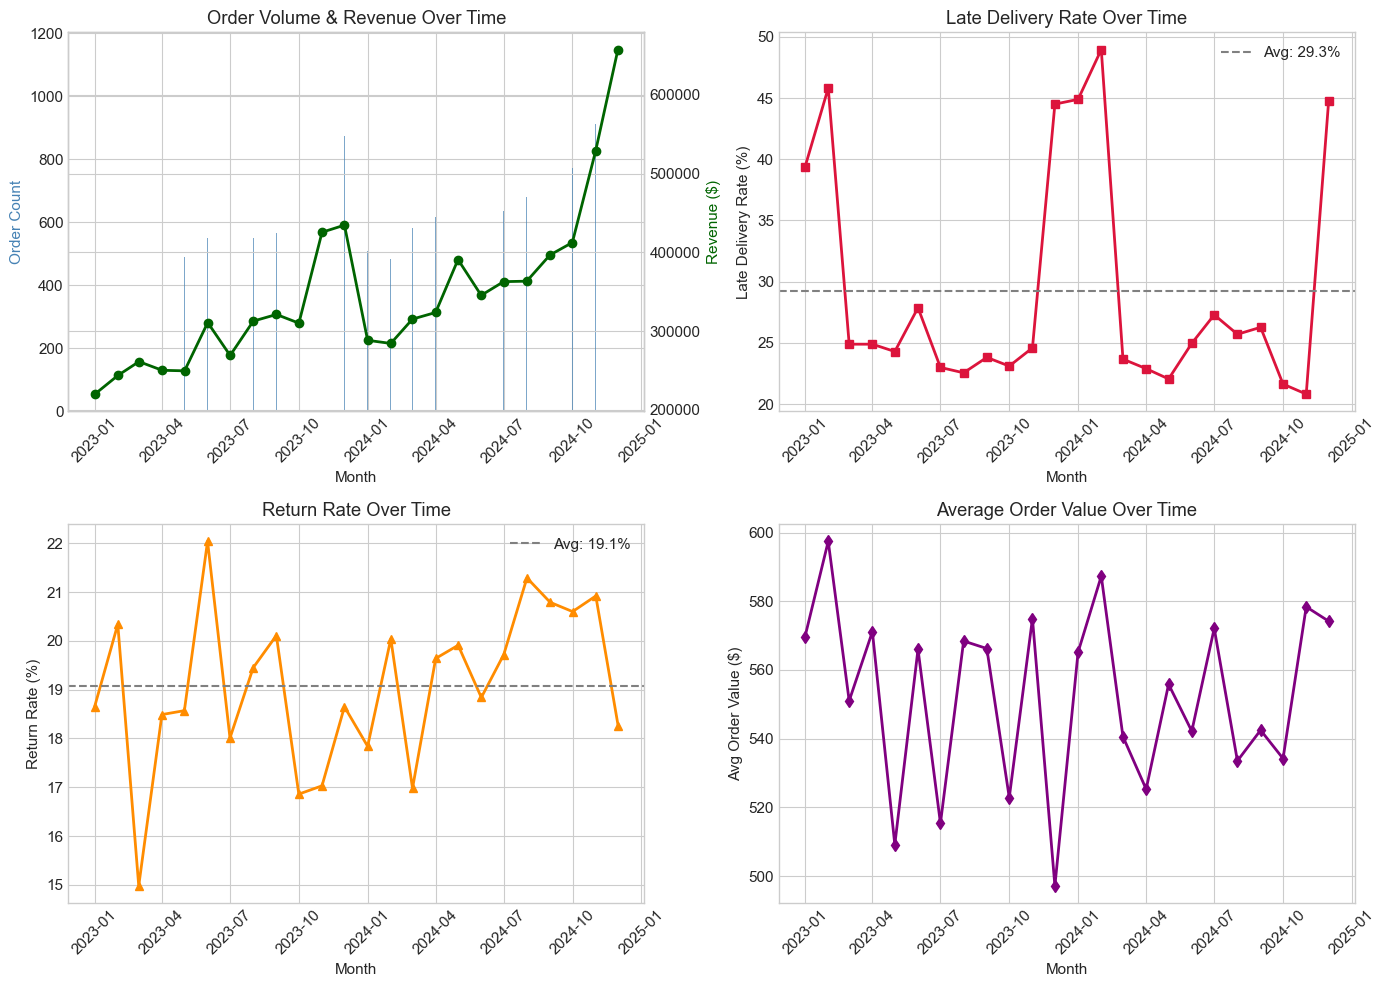


=== Key Observations ===
Total Orders: 15,000
Total Revenue: $8,276,008.83
Avg Monthly Late Rate: 29.28%
Avg Monthly Return Rate: 19.08%


In [23]:
# Create a multi-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Order Volume & Revenue
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.bar(df_monthly['order_month'], df_monthly['order_count'], alpha=0.7, label='Order Count', color='steelblue')
ax1_twin.plot(df_monthly['order_month'], df_monthly['gross_revenue'], color='darkgreen', linewidth=2, marker='o', label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='steelblue')
ax1_twin.set_ylabel('Revenue ($)', color='darkgreen')
ax1.set_title('Order Volume & Revenue Over Time')
ax1.tick_params(axis='x', rotation=45)

# Panel 2: Late Delivery Rate Over Time
ax2 = axes[0, 1]
ax2.plot(df_monthly['order_month'], df_monthly['late_pct'], color='crimson', linewidth=2, marker='s')
ax2.axhline(y=df_monthly['late_pct'].mean(), color='gray', linestyle='--', label=f"Avg: {df_monthly['late_pct'].mean():.1f}%")
ax2.set_xlabel('Month')
ax2.set_ylabel('Late Delivery Rate (%)')
ax2.set_title('Late Delivery Rate Over Time')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# Panel 3: Return Rate Over Time
ax3 = axes[1, 0]
ax3.plot(df_monthly['order_month'], df_monthly['return_pct'], color='darkorange', linewidth=2, marker='^')
ax3.axhline(y=df_monthly['return_pct'].mean(), color='gray', linestyle='--', label=f"Avg: {df_monthly['return_pct'].mean():.1f}%")
ax3.set_xlabel('Month')
ax3.set_ylabel('Return Rate (%)')
ax3.set_title('Return Rate Over Time')
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# Panel 4: Average Order Value
ax4 = axes[1, 1]
ax4.plot(df_monthly['order_month'], df_monthly['avg_order_value'], color='purple', linewidth=2, marker='d')
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Order Value ($)')
ax4.set_title('Average Order Value Over Time')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Key Observations ===")
print(f"Total Orders: {df_monthly['order_count'].sum():,}")
print(f"Total Revenue: ${df_monthly['gross_revenue'].sum():,.2f}")
print(f"Avg Monthly Late Rate: {df_monthly['late_pct'].mean():.2f}%")
print(f"Avg Monthly Return Rate: {df_monthly['return_pct'].mean():.2f}%")

---

## 3.2 Lifecycle Stage Duration Analysis (THE CORE)

**This is the heart of our bottleneck analysis.**

**Junior colleague, here's what you need to understand:**

An order goes through these stages:
```
Order Placed → Approved → Shipped → Delivered
     |            |           |          |
     +-- hours_to_approve --+           |
                  |                      |
                  +-- hours_to_ship ----+
                              |          |
                              +-- hours_in_transit --+
```

**Why we use Median AND Percentiles:**
- **Median (P50)**: The "typical" experience
- **P90**: 10% of orders take *longer* than this — these are your problem cases
- **P95**: The worst 5% — true outliers

**The gap between Median and P90 reveals bottlenecks!**
- If median approval = 5 hours but P90 = 22 hours → 10% of orders are getting stuck somewhere

In [24]:
query = """
SELECT
    'Approval' AS stage,
    1 AS stage_order,
    COUNT(*) AS sample_size,
    ROUND(MEDIAN(hours_to_approve), 1) AS median_hours,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_to_approve), 1) AS p90_hours,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY hours_to_approve), 1) AS p95_hours,
    ROUND(AVG(hours_to_approve), 1) AS mean_hours,
    ROUND(STDDEV(hours_to_approve), 1) AS std_hours
FROM sales_marts.mart_order_complete
WHERE hours_to_approve IS NOT NULL AND hours_to_approve >= 0

UNION ALL

SELECT
    'Processing & Shipping' AS stage,
    2 AS stage_order,
    COUNT(*) AS sample_size,
    ROUND(MEDIAN(hours_to_ship), 1) AS median_hours,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_to_ship), 1) AS p90_hours,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY hours_to_ship), 1) AS p95_hours,
    ROUND(AVG(hours_to_ship), 1) AS mean_hours,
    ROUND(STDDEV(hours_to_ship), 1) AS std_hours
FROM sales_marts.mart_order_complete
WHERE hours_to_ship IS NOT NULL AND hours_to_ship >= 0

UNION ALL

SELECT
    'In Transit' AS stage,
    3 AS stage_order,
    COUNT(*) AS sample_size,
    ROUND(MEDIAN(hours_in_transit), 1) AS median_hours,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_in_transit), 1) AS p90_hours,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY hours_in_transit), 1) AS p95_hours,
    ROUND(AVG(hours_in_transit), 1) AS mean_hours,
    ROUND(STDDEV(hours_in_transit), 1) AS std_hours
FROM sales_marts.mart_order_complete
WHERE hours_in_transit IS NOT NULL AND hours_in_transit >= 0

ORDER BY stage_order;
"""

df_lifecycle = pd.read_sql(query, conn)
df_lifecycle.columns = df_lifecycle.columns.str.lower()

print("=== Lifecycle Stage Duration Analysis ===")
print(df_lifecycle.to_string(index=False))

=== Lifecycle Stage Duration Analysis ===
                stage  stage_order  sample_size  median_hours  p90_hours  p95_hours  mean_hours  std_hours
             Approval            1        14625           5.0       23.0       36.0         9.6       13.1
Processing & Shipping            2        14321          21.0       87.0      125.0        37.1       48.2
           In Transit            3        13879          83.0      185.0      211.0        97.5       58.6


C:\Users\frase\AppData\Local\Temp\ipykernel_54904\3093432512.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lifecycle = pd.read_sql(query, conn)


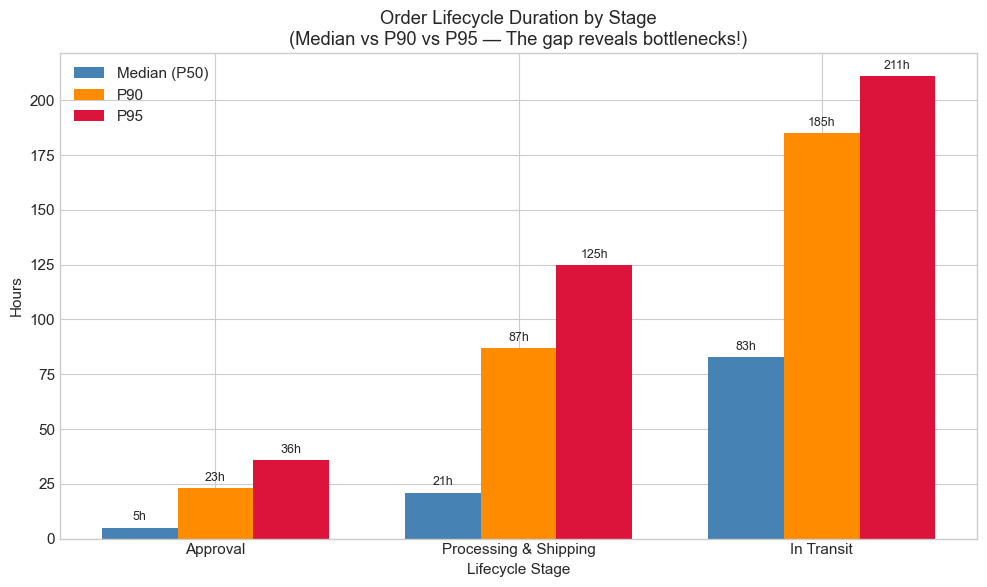


=== Bottleneck Indicators (P90 / Median ratio) ===
Approval: P90 is 4.6x the median → ⚠️ BOTTLENECK
Processing & Shipping: P90 is 4.1x the median → ⚠️ BOTTLENECK
In Transit: P90 is 2.2x the median → ⚠️ BOTTLENECK


In [25]:
# Visualize the lifecycle stages
fig, ax = plt.subplots(figsize=(10, 6))

stages = df_lifecycle['stage'].tolist()
x = np.arange(len(stages))
width = 0.25

bars1 = ax.bar(x - width, df_lifecycle['median_hours'], width, label='Median (P50)', color='steelblue')
bars2 = ax.bar(x, df_lifecycle['p90_hours'], width, label='P90', color='darkorange')
bars3 = ax.bar(x + width, df_lifecycle['p95_hours'], width, label='P95', color='crimson')

ax.set_xlabel('Lifecycle Stage')
ax.set_ylabel('Hours')
ax.set_title('Order Lifecycle Duration by Stage\n(Median vs P90 vs P95 — The gap reveals bottlenecks!)')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}h',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lifecycle_stages.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate the "tail factor" — how much worse is P90 compared to median?
print("\n=== Bottleneck Indicators (P90 / Median ratio) ===")
for _, row in df_lifecycle.iterrows():
    ratio = row['p90_hours'] / row['median_hours'] if row['median_hours'] > 0 else 0
    flag = "⚠️ BOTTLENECK" if ratio > 2 else "✓ Acceptable"
    print(f"{row['stage']}: P90 is {ratio:.1f}x the median → {flag}")

---

## 3.3 Segmented Bottleneck Discovery

**Now the powerful part — we break down each stage by dimension.**

**Junior colleague, this is where analysis becomes actionable:**

Saying "processing takes too long" isn't helpful. But saying "WH-Southeast takes 2x longer than other warehouses" is something operations can fix!

We'll analyze:
1. **Processing time by Warehouse** — Which facility is the bottleneck?
2. **Transit time by Carrier × Season** — Which carrier fails in winter?
3. **Approval time by Day Type** — Are weekends slower?

In [26]:
# Processing time by warehouse
query = """
SELECT
    warehouse_origin,
    COUNT(*) AS orders,
    ROUND(MEDIAN(hours_to_ship), 1) AS median_processing_hrs,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_to_ship), 1) AS p90_processing_hrs,
    ROUND(100.0 * SUM(CASE WHEN is_late_delivery = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS late_delivery_pct
FROM sales_marts.mart_order_complete
WHERE hours_to_ship IS NOT NULL AND hours_to_ship >= 0
GROUP BY warehouse_origin
ORDER BY median_processing_hrs DESC;
"""

df_warehouse = pd.read_sql(query, conn)
df_warehouse.columns = df_warehouse.columns.str.lower()

print("=== Processing Time by Warehouse ===")
print(df_warehouse.to_string(index=False))

=== Processing Time by Warehouse ===
warehouse_origin  orders  median_processing_hrs  p90_processing_hrs  late_delivery_pct
         WH-West    1921                   44.0               146.0              49.82
    WH-Southeast    3095                   43.0               116.0              29.79
    WH-Southwest    3837                   15.0                63.4              27.68
      WH-Midwest    2559                   14.0                60.0              27.35
      WH-Central    2909                   12.0                35.0              25.89


C:\Users\frase\AppData\Local\Temp\ipykernel_54904\2794629225.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_warehouse = pd.read_sql(query, conn)


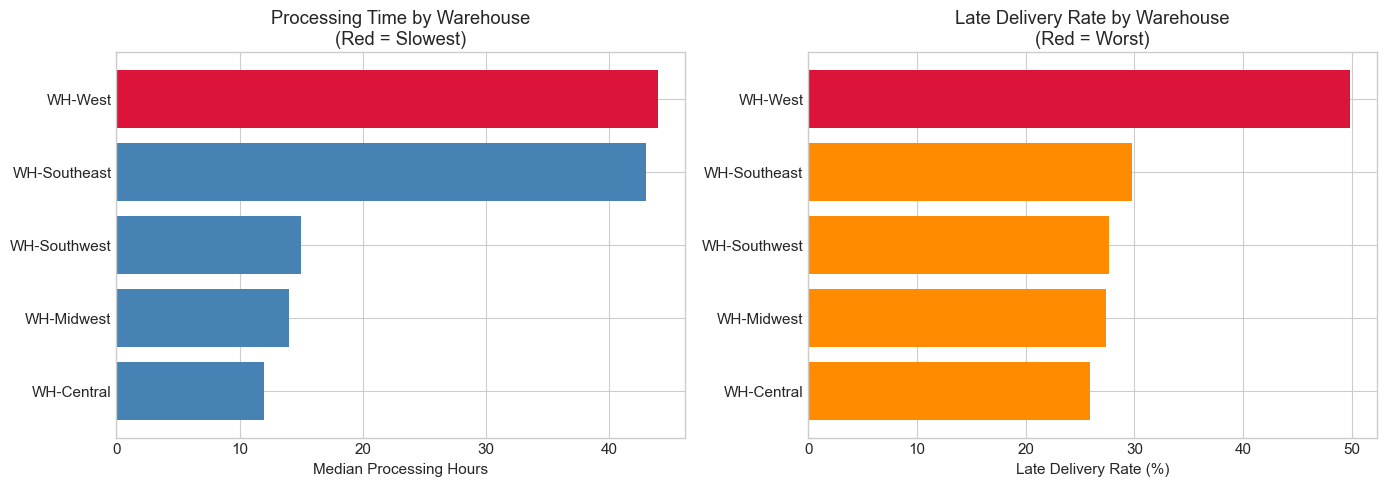

In [27]:
# Visualize warehouse performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Processing time by warehouse
ax1 = axes[0]
colors = ['crimson' if x == df_warehouse['median_processing_hrs'].max() else 'steelblue' 
          for x in df_warehouse['median_processing_hrs']]
bars = ax1.barh(df_warehouse['warehouse_origin'], df_warehouse['median_processing_hrs'], color=colors)
ax1.set_xlabel('Median Processing Hours')
ax1.set_title('Processing Time by Warehouse\n(Red = Slowest)')
ax1.invert_yaxis()

# Chart 2: Late delivery rate by warehouse
ax2 = axes[1]
colors2 = ['crimson' if x == df_warehouse['late_delivery_pct'].max() else 'darkorange' 
           for x in df_warehouse['late_delivery_pct']]
bars2 = ax2.barh(df_warehouse['warehouse_origin'], df_warehouse['late_delivery_pct'], color=colors2)
ax2.set_xlabel('Late Delivery Rate (%)')
ax2.set_title('Late Delivery Rate by Warehouse\n(Red = Worst)')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('warehouse_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Transit time by carrier x season
query = """
SELECT
    carrier,
    CASE 
        WHEN MONTH(order_ts) IN (12, 1, 2) THEN 'Winter'
        WHEN MONTH(order_ts) IN (3, 4, 5) THEN 'Spring'
        WHEN MONTH(order_ts) IN (6, 7, 8) THEN 'Summer'
        ELSE 'Fall' 
    END AS season,
    COUNT(*) AS orders,
    ROUND(MEDIAN(hours_in_transit), 1) AS median_transit_hrs,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_in_transit), 1) AS p90_transit_hrs
FROM sales_marts.mart_order_complete
WHERE hours_in_transit IS NOT NULL AND hours_in_transit >= 0
GROUP BY carrier, season
ORDER BY carrier, 
    CASE season 
        WHEN 'Winter' THEN 1 
        WHEN 'Spring' THEN 2 
        WHEN 'Summer' THEN 3 
        ELSE 4 
    END;
"""

df_carrier_season = pd.read_sql(query, conn)
df_carrier_season.columns = df_carrier_season.columns.str.lower()

print("=== Transit Time by Carrier × Season ===")
print(df_carrier_season.to_string(index=False))

C:\Users\frase\AppData\Local\Temp\ipykernel_54904\1707691933.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_carrier_season = pd.read_sql(query, conn)


=== Transit Time by Carrier × Season ===
        carrier season  orders  median_transit_hrs  p90_transit_hrs
     BudgetPost Winter     962               220.0            283.0
     BudgetPost Spring     805               150.0            205.0
     BudgetPost Summer     898               150.0            204.0
     BudgetPost   Fall    1070               144.0            202.0
ExpressCarriers Winter     399                43.0             51.2
ExpressCarriers Spring     354                36.0             47.0
ExpressCarriers Summer     389                37.0             47.0
ExpressCarriers   Fall     507                37.0             46.0
       FastShip Winter     415                57.0             77.6
       FastShip Spring     420                48.0             68.0
       FastShip Summer     434                51.0             71.0
       FastShip   Fall     525                49.0             70.0
     NationWide Winter     862               124.0            162.0
     Na

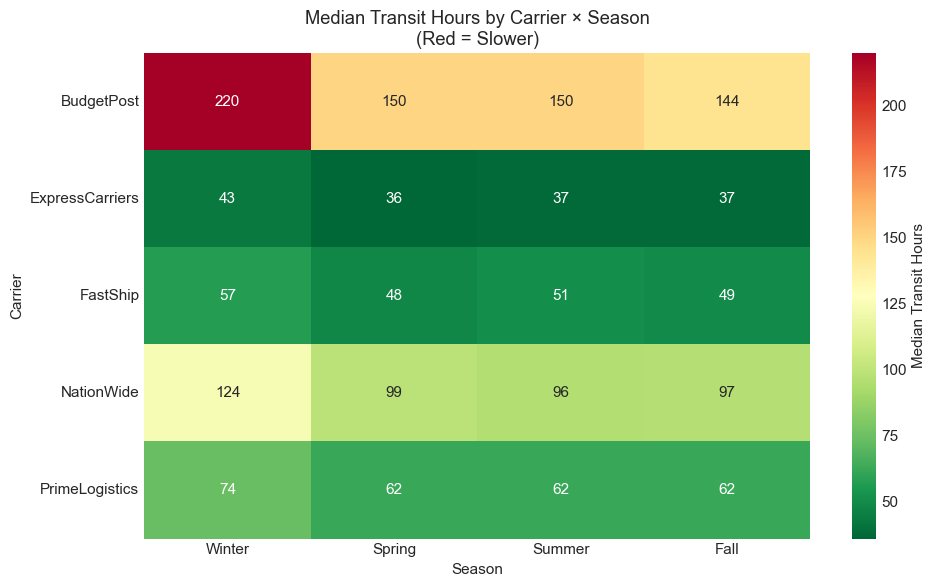


=== Worst Carrier × Season Combinations ===
  BudgetPost in Winter: 220h median, 283h P90
  BudgetPost in Spring: 150h median, 205h P90
  BudgetPost in Summer: 150h median, 204h P90


In [29]:
# Create heatmap for carrier x season
pivot_median = df_carrier_season.pivot(index='carrier', columns='season', values='median_transit_hrs')
pivot_median = pivot_median[['Winter', 'Spring', 'Summer', 'Fall']]  # Order seasons

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_median, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Median Transit Hours'}, ax=ax)
ax.set_title('Median Transit Hours by Carrier × Season\n(Red = Slower)')
ax.set_xlabel('Season')
ax.set_ylabel('Carrier')

plt.tight_layout()
plt.savefig('carrier_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify the worst combinations
print("\n=== Worst Carrier × Season Combinations ===")
worst = df_carrier_season.nlargest(3, 'median_transit_hrs')
for _, row in worst.iterrows():
    print(f"  {row['carrier']} in {row['season']}: {row['median_transit_hrs']:.0f}h median, {row['p90_transit_hrs']:.0f}h P90")

In [30]:
# Approval time: weekday vs weekend
query = """
SELECT
    CASE WHEN is_weekend_order = 1 THEN 'Weekend' ELSE 'Weekday' END AS day_type,
    COUNT(*) AS orders,
    ROUND(MEDIAN(hours_to_approve), 1) AS median_approval_hrs,
    ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY hours_to_approve), 1) AS p90_approval_hrs,
    ROUND(AVG(hours_to_approve), 1) AS mean_approval_hrs
FROM sales_marts.mart_order_complete
WHERE hours_to_approve IS NOT NULL AND hours_to_approve >= 0
GROUP BY day_type
ORDER BY day_type;
"""

df_weekend = pd.read_sql(query, conn)
df_weekend.columns = df_weekend.columns.str.lower()

print("=== Approval Time: Weekday vs Weekend ===")
print(df_weekend.to_string(index=False))

# Calculate the difference
weekend_median = df_weekend[df_weekend['day_type'] == 'Weekend']['median_approval_hrs'].values[0]
weekday_median = df_weekend[df_weekend['day_type'] == 'Weekday']['median_approval_hrs'].values[0]
diff_pct = ((weekend_median - weekday_median) / weekday_median) * 100

print(f"\nWeekend orders take {diff_pct:.1f}% longer to approve than weekday orders")
print("→ This suggests reduced staffing or processing on weekends")

=== Approval Time: Weekday vs Weekend ===
day_type  orders  median_approval_hrs  p90_approval_hrs  mean_approval_hrs
 Weekday   10467                  3.0              10.0                4.5
 Weekend    4158                 17.0              46.0               22.3

Weekend orders take 466.7% longer to approve than weekday orders
→ This suggests reduced staffing or processing on weekends


C:\Users\frase\AppData\Local\Temp\ipykernel_54904\984376524.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_weekend = pd.read_sql(query, conn)


---

## 3.4 Return Rate Deep Dive

**Returns are expensive** — not just the refund, but shipping, restocking, and lost customer trust.

**Key questions we're answering:**
1. Which product categories have the highest return rates?
2. Do certain warehouses have quality/packaging issues?
3. **Does late delivery cause more returns?** (Critical hypothesis!)

In [31]:
# Return rate by category x warehouse
query = """
SELECT
    primary_category,
    warehouse_origin,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END) AS returned_orders,
    ROUND(100.0 * SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS return_rate_pct,
    ROUND(SUM(COALESCE(total_refund, 0)), 2) AS total_refund_cost
FROM sales_marts.mart_order_complete
WHERE primary_category IS NOT NULL
GROUP BY primary_category, warehouse_origin
HAVING COUNT(*) >= 30
ORDER BY return_rate_pct DESC;
"""

df_returns = pd.read_sql(query, conn)
df_returns.columns = df_returns.columns.str.lower()

print("=== Return Rate by Category × Warehouse (Top 15) ===")
print(df_returns.head(15).to_string(index=False))

C:\Users\frase\AppData\Local\Temp\ipykernel_54904\3638351090.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_returns = pd.read_sql(query, conn)


=== Return Rate by Category × Warehouse (Top 15) ===
 primary_category warehouse_origin  total_orders  returned_orders  return_rate_pct  total_refund_cost
      Electronics     WH-Southeast           639              269            42.10          212932.07
         Clothing          WH-West           202               77            38.12           18264.47
      Electronics     WH-Southwest           777              242            31.15          151269.28
      Electronics          WH-West           382              117            30.63           68229.15
         Clothing       WH-Midwest           238               71            29.83           15674.76
         Clothing     WH-Southeast           330               94            28.48           18152.01
      Electronics       WH-Central           572              160            27.97          105769.04
         Clothing     WH-Southwest           423              117            27.66           23561.12
         Clothing       WH-Ce

In [32]:
# Do late deliveries cause more returns? (Critical analysis!)
query = """
SELECT
    CASE WHEN is_late_delivery = 1 THEN 'Late' ELSE 'On-Time' END AS delivery_status,
    COUNT(*) AS orders,
    SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END) AS returns,
    ROUND(100.0 * SUM(CASE WHEN has_return = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS return_rate_pct
FROM sales_marts.mart_order_complete
GROUP BY delivery_status
ORDER BY delivery_status;
"""

df_late_returns = pd.read_sql(query, conn)
df_late_returns.columns = df_late_returns.columns.str.lower()

print("=== Return Rate: Late vs On-Time Delivery ===")
print(df_late_returns.to_string(index=False))

late_rate = df_late_returns[df_late_returns['delivery_status'] == 'Late']['return_rate_pct'].values[0]
ontime_rate = df_late_returns[df_late_returns['delivery_status'] == 'On-Time']['return_rate_pct'].values[0]
lift = ((late_rate - ontime_rate) / ontime_rate) * 100

print(f"\n⚠️ CRITICAL FINDING:")
print(f"   Late deliveries have a {lift:.1f}% higher return rate than on-time deliveries!")
print(f"   ({late_rate:.2f}% vs {ontime_rate:.2f}%)")
print(f"\n   → This will be statistically validated in Phase 4")

=== Return Rate: Late vs On-Time Delivery ===
delivery_status  orders  returns  return_rate_pct
           Late    4394      965            21.96
        On-Time   10606     1907            17.98

⚠️ CRITICAL FINDING:
   Late deliveries have a 22.1% higher return rate than on-time deliveries!
   (21.96% vs 17.98%)

   → This will be statistically validated in Phase 4


C:\Users\frase\AppData\Local\Temp\ipykernel_54904\4281901319.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_late_returns = pd.read_sql(query, conn)


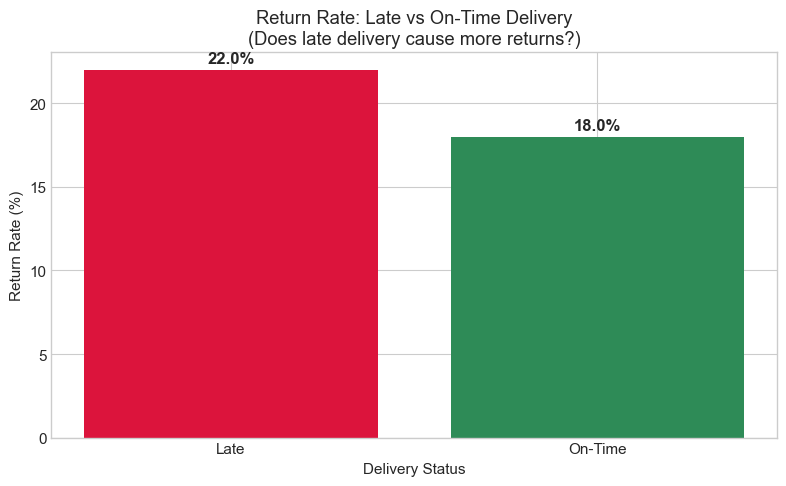

In [33]:
# Visualize late delivery impact on returns
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['crimson', 'seagreen']
bars = ax.bar(df_late_returns['delivery_status'], df_late_returns['return_rate_pct'], color=colors)

ax.set_xlabel('Delivery Status')
ax.set_ylabel('Return Rate (%)')
ax.set_title('Return Rate: Late vs On-Time Delivery\n(Does late delivery cause more returns?)')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('late_delivery_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3.5 Marketing Channel Efficiency

**Junior colleague, here are the key marketing metrics:**

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **ROAS** | Revenue / Spend | Return on Ad Spend — how many dollars back per dollar spent |
| **CPA** | Spend / Conversions | Cost Per Acquisition — how much to acquire one customer |
| **CPC** | Spend / Clicks | Cost Per Click |
| **CTR** | Clicks / Impressions | Click-Through Rate — ad effectiveness |

In [34]:
# Marketing channel efficiency
query = """
SELECT
    channel,
    ROUND(SUM(spend), 2) AS total_spend,
    SUM(conversions) AS total_conversions,
    ROUND(SUM(revenue_attributed), 2) AS total_revenue,
    ROUND(SUM(revenue_attributed) / NULLIF(SUM(spend), 0), 2) AS roas,
    ROUND(SUM(spend) / NULLIF(SUM(conversions), 0), 2) AS cpa
FROM sales_raw."10_MARKETING_CAMPAIGNS"
WHERE spend > 0
GROUP BY channel
ORDER BY roas DESC;
"""

df_marketing = pd.read_sql(query, conn)
df_marketing.columns = df_marketing.columns.str.lower()

print("=== Marketing Channel Performance ===")
print(df_marketing.to_string(index=False))

C:\Users\frase\AppData\Local\Temp\ipykernel_54904\2818947646.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_marketing = pd.read_sql(query, conn)


=== Marketing Channel Performance ===
        channel  total_spend  total_conversions  total_revenue  roas   cpa
Email Marketing     62812.36               6981      595619.52  9.48  9.00
     Google Ads    439377.77              31957     2845484.62  6.48 13.75
    YouTube Ads    251400.49              12168     1047688.66  4.17 20.66
 Organic Search     15992.59                682       59839.16  3.74 23.45
   Facebook Ads    369114.18              15630     1279350.38  3.47 23.62
       Referral     42483.86               1766      128173.42  3.02 24.06
      Affiliate    158237.11               5066      420677.37  2.66 31.24
  Instagram Ads    265265.73               8675      678814.87  2.56 30.58
     TikTok Ads    168379.85               2344      198503.16  1.18 71.83


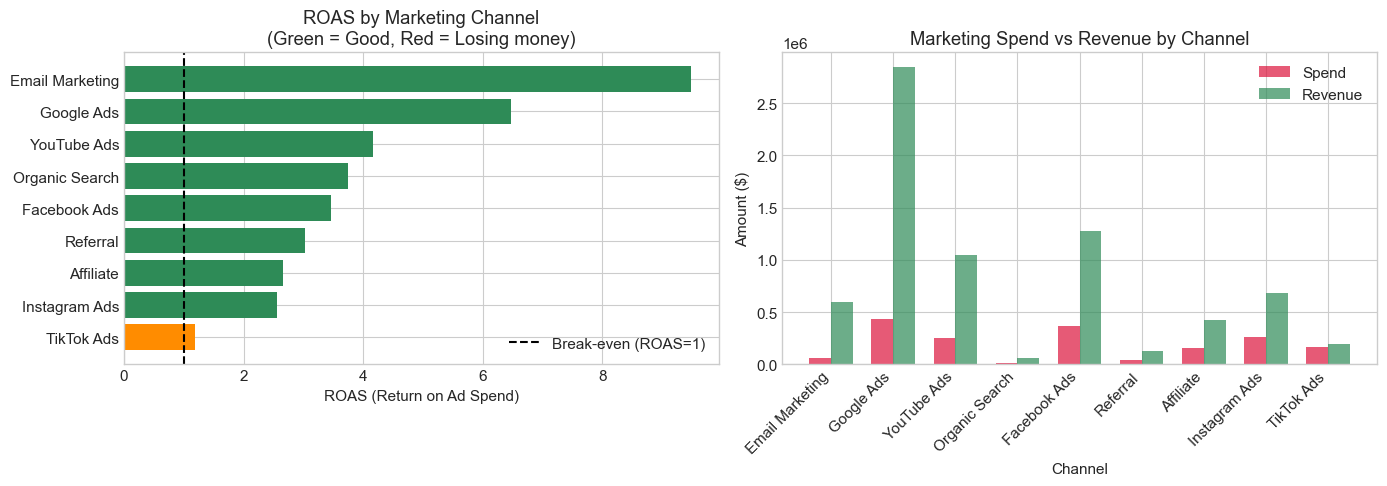

In [35]:
# Visualize marketing performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: ROAS by channel
ax1 = axes[0]
colors_roas = ['seagreen' if x >= 2 else 'darkorange' if x >= 1 else 'crimson' for x in df_marketing['roas']]
bars1 = ax1.barh(df_marketing['channel'], df_marketing['roas'], color=colors_roas)
ax1.axvline(x=1, color='black', linestyle='--', label='Break-even (ROAS=1)')
ax1.set_xlabel('ROAS (Return on Ad Spend)')
ax1.set_title('ROAS by Marketing Channel\n(Green = Good, Red = Losing money)')
ax1.legend()
ax1.invert_yaxis()

# Chart 2: Spend vs Revenue
ax2 = axes[1]
x = np.arange(len(df_marketing))
width = 0.35
bars2a = ax2.bar(x - width/2, df_marketing['total_spend'], width, label='Spend', color='crimson', alpha=0.7)
bars2b = ax2.bar(x + width/2, df_marketing['total_revenue'], width, label='Revenue', color='seagreen', alpha=0.7)
ax2.set_xlabel('Channel')
ax2.set_ylabel('Amount ($)')
ax2.set_title('Marketing Spend vs Revenue by Channel')
ax2.set_xticks(x)
ax2.set_xticklabels(df_marketing['channel'], rotation=45, ha='right')
ax2.legend()

plt.tight_layout()
plt.savefig('marketing_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---

## EDA Summary: Key Hypotheses for Statistical Validation

Based on our exploratory analysis, we've identified the following hypotheses to test in Phase 4:

| # | Hypothesis | Observed Pattern | Next Step |
|---|------------|------------------|------------|
| H1 | Weekend orders take longer to approve | Weekend median (17h) >> Weekday median (3h) | Mann-Whitney U test |
| H2 | Certain carriers perform worse in winter | BudgetPost winter transit (220h) >> other seasons (~150h) | Mann-Whitney U test |
| H3 | WH-West has slower processing | Highest median processing time (44h vs 12-43h others) | Mann-Whitney U test |
| H4 | Late delivery causes more returns | Late return rate (21.96%) >> On-time (17.98%) | Chi-square test |

**Junior colleague, remember:**
> Visual patterns are hypotheses, not conclusions. We need statistical tests to prove these patterns are real and not just random variation!

In [36]:
# Save key dataframes for Phase 4
df_monthly.to_csv('eda_monthly_trends.csv', index=False)
df_lifecycle.to_csv('eda_lifecycle_stages.csv', index=False)
df_warehouse.to_csv('eda_warehouse_performance.csv', index=False)
df_carrier_season.to_csv('eda_carrier_season.csv', index=False)
df_late_returns.to_csv('eda_late_returns.csv', index=False)

print("EDA data saved for Phase 4 statistical validation!")

EDA data saved for Phase 4 statistical validation!


In [37]:
conn.close()
print("Connection closed.")

Connection closed.
